# UID Paper Replication - Complete Implementation

For Google Colab with actual dataset from my drive folder

In [1]:
# STEP 0: Configuration
import os

# Mount Drive only when running in Colab.
try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')
except Exception:
    pass


def first_existing(candidates):
    for p in candidates:
        if p and os.path.exists(p):
            return p
    return candidates[0]

# Experiment profile: 'paper' (closer to reported setup) or 'quick'.
RUN_PROFILE = 'paper'
PROFILE_SETTINGS = {
    'paper': {
        'max_train': 5000,
        'max_test': 500,
        'max_variants': 99,
    },
    'quick': {
        'max_train': 1000,
        'max_test': 100,
        'max_variants': 20,
    },
}

settings = PROFILE_SETTINGS[RUN_PROFILE]
MAX_TRAIN = settings['max_train']
MAX_TEST = settings['max_test']
MAX_VARIANTS = settings['max_variants']
N_FOLDS = 5
RANDOM_SEED = 42

# Hindi paths (paper replication target language)
TRAIN_PATH = first_existing([
    '/content/drive/MyDrive/MTP/Projects/UID_replication/Datasets/hi_hdtb-ud-train.conllu',
    '/content/drive/MyDrive/MTP/Projects/UID_replication/Datasets/hi_train.conllu',
    'UID_Replication/Datasets/UD_Hindi-HDTB/hi_hdtb-ud-train.conllu',
])
DEV_PATH = first_existing([
    '/content/drive/MyDrive/MTP/Projects/UID_replication/Datasets/hi_hdtb-ud-dev.conllu',
    '/content/drive/MyDrive/MTP/Projects/UID_replication/Datasets/hi_dev.conllu',
    'UID_Replication/Datasets/UD_Hindi-HDTB/hi_hdtb-ud-dev.conllu',
])
TEST_PATH = first_existing([
    '/content/drive/MyDrive/MTP/Projects/UID_replication/Datasets/hi_hdtb-ud-test.conllu',
    '/content/drive/MyDrive/MTP/Projects/UID_replication/Datasets/hi_test.conllu',
    'UID_Replication/Datasets/UD_Hindi-HDTB/hi_hdtb-ud-test.conllu',
])

# Optional English paths for contrastive diagnostics.
EN_TRAIN_PATH = os.environ.get('EN_TRAIN_PATH', '')
EN_DEV_PATH = os.environ.get('EN_DEV_PATH', '')
EN_TEST_PATH = os.environ.get('EN_TEST_PATH', '')

print('Configuration:')
print(f'  RUN_PROFILE={RUN_PROFILE}')
print(f'  MAX_TRAIN={MAX_TRAIN}, MAX_TEST={MAX_TEST}, MAX_VARIANTS={MAX_VARIANTS}')
print(f'  TRAIN_PATH={TRAIN_PATH}')
print(f'  DEV_PATH={DEV_PATH}')
print(f'  TEST_PATH={TEST_PATH}')
if EN_TEST_PATH:
    print(f'  EN_TEST_PATH={EN_TEST_PATH}')
else:
    print('  EN_TEST_PATH not set (Hindi-only run by default).')


Configuration:
  RUN_PROFILE=paper
  MAX_TRAIN=5000, MAX_TEST=500, MAX_VARIANTS=99
  TRAIN_PATH=/content/drive/MyDrive/MTP/Projects/UID_replication/Datasets/hi_hdtb-ud-train.conllu
  DEV_PATH=/content/drive/MyDrive/MTP/Projects/UID_replication/Datasets/hi_hdtb-ud-dev.conllu
  TEST_PATH=/content/drive/MyDrive/MTP/Projects/UID_replication/Datasets/hi_hdtb-ud-test.conllu
  EN_TEST_PATH not set (Hindi-only run by default).


In [2]:
# IMPORTS
import os, math, random
from collections import defaultdict, Counter
from itertools import permutations
import numpy as np
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [3]:
# DATA STRUCTURES
class Token:
    def __init__(self, id, form, lemma, upos, xpos, feats, head, deprel, deps, misc):
        self.id = id
        self.form = form
        self.lemma = lemma
        self.upos = upos
        self.xpos = xpos
        self.feats = feats
        self.head = head
        self.deprel = deprel
        self.deps = deps
        self.misc = misc

class Sentence:
    def __init__(self, sent_id, text, tokens):
        self.sent_id = sent_id
        self.text = text
        self.tokens = tokens

    def ordered_tokens(self):
        return sorted(self.tokens, key=lambda t: t.id)

    def get_root(self):
        return next((t for t in self.tokens if t.head == 0), None)

    def get_word_sequence(self):
        return [t.form for t in self.ordered_tokens()]

    def get_preverbal_constituents(self):
        # Collect preverbal root-dependent subtrees as reorderable constituents.
        root = self.get_root()
        if not root:
            return []

        tokens = self.ordered_tokens()
        id_to_token = {t.id: t for t in tokens}
        children = defaultdict(list)
        for t in tokens:
            children[t.head].append(t.id)
        for hid in children:
            children[hid].sort()

        constituents = []
        assigned_ids = set()

        # Constituents are subtrees rooted in preverbal dependents of the main root.
        for dep_id in children.get(root.id, []):
            if dep_id >= root.id:
                continue

            stack = [dep_id]
            subtree_ids = []
            while stack:
                curr = stack.pop()
                if curr in assigned_ids:
                    continue
                tok = id_to_token[curr]
                if tok.id >= root.id:
                    continue
                subtree_ids.append(curr)
                stack.extend(children.get(curr, []))

            if subtree_ids:
                subtree_ids = sorted(subtree_ids)
                assigned_ids.update(subtree_ids)
                constituents.append([id_to_token[sid] for sid in subtree_ids])

        # Keep any remaining preverbal token as singleton constituent.
        for tok in tokens:
            if tok.id < root.id and tok.id not in assigned_ids:
                constituents.append([tok])
                assigned_ids.add(tok.id)

        constituents.sort(key=lambda c: c[0].id)
        return constituents


In [4]:
# CoNLL-U PARSER

def parse_feats(feats_str):
    feats = {}
    if feats_str and feats_str != '_':
        for feat in feats_str.split('|'):
            if '=' in feat:
                key, value = feat.split('=', 1)
                feats[key] = value
    return feats

def parse_conllu(filepath, max_sent=None):
    sentences = []
    current_tokens = []
    sent_id = ''
    text = ''

    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line.startswith('# sent_id'):
                sent_id = line.split('=', 1)[1].strip() if '=' in line else ''
            elif line.startswith('# text'):
                text = line.split('=', 1)[1].strip() if '=' in line else ''
            elif line == '':
                if current_tokens:
                    sentences.append(Sentence(sent_id, text, current_tokens))
                    current_tokens = []
                    sent_id = ''
                    text = ''
                    if max_sent and len(sentences) >= max_sent:
                        break
            else:
                fields = line.split('\t')
                if len(fields) == 10 and '-' not in fields[0] and '.' not in fields[0]:
                    token = Token(
                        id=int(fields[0]), form=fields[1], lemma=fields[2],
                        upos=fields[3], xpos=fields[4], feats=parse_feats(fields[5]),
                        head=int(fields[6]) if fields[6] != '_' else 0,
                        deprel=fields[7], deps=fields[8], misc=fields[9]
                    )
                    current_tokens.append(token)

    if current_tokens:
        sentences.append(Sentence(sent_id, text, current_tokens))
    return sentences

In [5]:
# CoNLL-U parsing with `conllu` library (reference implementation)

import sys
import subprocess

try:
    from conllu import parse_incr
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'conllu'])
    from conllu import parse_incr


def parse_conllu_with_conllu(filepath, max_sent=None):
    sentences = []

    with open(filepath, 'r', encoding='utf-8') as f:
        for i, tokenlist in enumerate(parse_incr(f)):
            sent_id = tokenlist.metadata.get('sent_id', '')
            text = tokenlist.metadata.get('text', '')
            tokens = []

            for tok in tokenlist:
                tok_id = tok.get('id')
                # Skip multiword tokens and empty nodes to match our parser behavior.
                if not isinstance(tok_id, int):
                    continue

                head = tok.get('head')
                tokens.append(Token(
                    id=tok_id,
                    form=tok.get('form', ''),
                    lemma=tok.get('lemma', '_'),
                    upos=tok.get('upos', '_'),
                    xpos=tok.get('xpos', '_'),
                    feats=dict(tok.get('feats') or {}),
                    head=head if isinstance(head, int) else 0,
                    deprel=tok.get('deprel', '_'),
                    deps=tok.get('deps', '_'),
                    misc=tok.get('misc', '_'),
                ))

            if tokens:
                sentences.append(Sentence(sent_id, text, tokens))

            if max_sent and len(sentences) >= max_sent:
                break

    return sentences

# Quick demo (parses a few sentences if one of the configured paths exists)
temp_path = next((p for p in [globals().get('TEST_PATH'), globals().get('DEV_PATH'), globals().get('TRAIN_PATH')] if isinstance(p, str) and os.path.exists(p)), None)
if temp_path:
    demo_sentence = parse_conllu_with_conllu(temp_path, max_sent=2)
    print(f'conllu parser demo: parsed {len(demo_sentence)} sentence(s) from {temp_path}')
    if demo_sentence:
        print(f'  First sent_id: {demo_sentence[0].sent_id}')
        print(f'  First text: {demo_sentence[0].text}')
        print(f'  First words: {demo_sentence[0].get_word_sequence()[:15]}')
else:
    print('conllu parser cell ready. Set TRAIN_PATH/DEV_PATH/TEST_PATH to run the demo.')


conllu parser cell ready. Set TRAIN_PATH/DEV_PATH/TEST_PATH to run the demo.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [6]:
# STEP 2: LOAD DATA + VOLUME CHECKS

def count_conllu_sentences(filepath):
    if not filepath or not os.path.exists(filepath):
        return 0
    n = 0
    has_token = False
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith('#'):
                has_token = True
            elif not line and has_token:
                n += 1
                has_token = False
    if has_token:
        n += 1
    return n

print('Loading data...')

available_train = count_conllu_sentences(TRAIN_PATH)
available_dev = count_conllu_sentences(DEV_PATH)
available_test = count_conllu_sentences(TEST_PATH)

train_limit = min(MAX_TRAIN, available_train) if MAX_TRAIN else available_train
test_limit = min(MAX_TEST, available_test) if MAX_TEST else available_test

print('Hindi sentence volumes:')
print(f'  available -> train={available_train}, dev={available_dev}, test={available_test}')
print(f'  selected  -> train={train_limit}, dev={available_dev}, test={test_limit}')

train_sentences = parse_conllu(TRAIN_PATH, train_limit)
dev_sentences = parse_conllu(DEV_PATH)
test_sentences = parse_conllu(TEST_PATH, test_limit)

print(f'Loaded Hindi: {len(train_sentences)} train, {len(dev_sentences)} dev, {len(test_sentences)} test.')

# Optional: load English splits if provided, for paper-context diagnostics.
english_train_sentences = []
english_dev_sentences = []
english_test_sentences = []

if EN_TRAIN_PATH and EN_DEV_PATH and EN_TEST_PATH and all(os.path.exists(p) for p in [EN_TRAIN_PATH, EN_DEV_PATH, EN_TEST_PATH]):
    en_available_train = count_conllu_sentences(EN_TRAIN_PATH)
    en_available_dev = count_conllu_sentences(EN_DEV_PATH)
    en_available_test = count_conllu_sentences(EN_TEST_PATH)

    en_train_limit = min(MAX_TRAIN, en_available_train) if MAX_TRAIN else en_available_train
    en_test_limit = min(MAX_TEST, en_available_test) if MAX_TEST else en_available_test

    english_train_sentences = parse_conllu(EN_TRAIN_PATH, en_train_limit)
    english_dev_sentences = parse_conllu(EN_DEV_PATH)
    english_test_sentences = parse_conllu(EN_TEST_PATH, en_test_limit)

    print('Loaded English: '
          f'{len(english_train_sentences)} train, '
          f'{len(english_dev_sentences)} dev, '
          f'{len(english_test_sentences)} test.')
else:
    print('English paths not fully configured. Hindi-English contrast table will be skipped.')


Loading data...
Hindi sentence volumes:
  available -> train=0, dev=0, test=0
  selected  -> train=0, dev=0, test=0


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/MTP/Projects/UID_replication/Datasets/hi_hdtb-ud-train.conllu'

In [ ]:
def evaluate_lambdas(l3, l2, l1, sentences):
    total_surprisal = 0
    word_count = 0

    for sent in sentences:
        words = sent.get_word_sequence()
        tokens = ['<s>', '<s>'] + words + ['</s>']

        for i in range(2, len(tokens)):
            tri = trigram_counts.get((tokens[i-2], tokens[i-1], tokens[i]), 0)
            bi_ctx = bigram_counts.get((tokens[i-2], tokens[i-1]), 0)
            p3 = tri / bi_ctx if bi_ctx > 0 else 0

            bi = bigram_counts.get((tokens[i-1], tokens[i]), 0)
            uni_ctx = unigram_counts.get(tokens[i-1], 0)
            p2 = bi / uni_ctx if uni_ctx > 0 else 0

            p1 = (unigram_counts.get(tokens[i], 0) + 1) / (total_tokens + vocab_size)

            prob = (l3 * p3) + (l2 * p2) + (l1 * p1)
            total_surprisal += -math.log2(max(prob, 1e-10))
            word_count += 1

    return total_surprisal / word_count

# Only run grid search if training data is already processed
if 'vocab_size' in globals():
    best_score = float('inf')
    best_lambdas = (0.5, 0.4, 0.1)

    print("Searching for optimal lambdas on Dev set...")
    for l3_int in range(1, 10):
        for l2_int in range(1, 10 - l3_int):
            l3 = l3_int / 10.0
            l2 = l2_int / 10.0
            l1 = 1.0 - l3 - l2

            score = evaluate_lambdas(l3, l2, l1, dev_sentences[:200])
            if score < best_score:
                best_score = score
                best_lambdas = (l3, l2, l1)

    print(f"Optimal Lambdas Found: Trigram={best_lambdas[0]}, Bigram={best_lambdas[1]}, Unigram={round(best_lambdas[2],1)}")
    print(f"Minimum average bits per word: {round(best_score, 4)}")
else:
    print("Dependency Missing: Please run 'STEP 3: TRAIN MODELS' (cell omB59KotI4MN) first to define 'vocab_size'.")

Searching for optimal lambdas on Dev set...
Optimal Lambdas Found: Trigram=0.1, Bigram=0.4, Unigram=0.5
Minimum average bits per word: 8.6143


In [ ]:
import math

# PAPER-ALIGNED SETTINGS (NO SRILM)
# The paper uses SRILM trigram surprisal; here we approximate with
# interpolated MLE n-grams over the same training corpus.
DEFAULT_LEX_LAMBDAS = (0.6, 0.3, 0.1)
LEXICAL_FLOOR = 1e-12
SYNTACTIC_ALPHA = 0.1
MAX_ANALYSIS_SENTENCES = 100


In [ ]:
# STEP 3: TRAIN LEXICAL MODEL (TRIGRAM COUNTS)
unigram_counts, bigram_counts, trigram_counts = Counter(), Counter(), Counter()
vocab, total_tokens = set(), 0

print('Training lexical trigram model...')

for sent in train_sentences:
    words = sent.get_word_sequence()
    tokens = ['<s>', '<s>'] + words + ['</s>']

    for i, tok in enumerate(tokens):
        unigram_counts[tok] += 1
        vocab.add(tok)

        if i > 0:
            bigram_counts[(tokens[i - 1], tok)] += 1

        if i > 1:
            trigram_counts[(tokens[i - 2], tokens[i - 1], tok)] += 1

    total_tokens += len(words)

vocab_size = len(vocab)
print(f'Vocabulary size: {vocab_size}')
print(f'Total tokens: {total_tokens}')
print(f'Unigrams: {len(unigram_counts)}, Bigrams: {len(bigram_counts)}, Trigrams: {len(trigram_counts)}')


In [ ]:
# LEXICAL SURPRISAL FUNCTIONS

def get_trigram_prob(word, prev1, prev2, lambdas=None):
    l3, l2, l1 = lambdas if lambdas is not None else globals().get('best_lambdas', DEFAULT_LEX_LAMBDAS)

    tri_count = trigram_counts.get((prev2, prev1, word), 0)
    tri_ctx = bigram_counts.get((prev2, prev1), 0)
    p3 = tri_count / tri_ctx if tri_ctx > 0 else 0.0

    bi_count = bigram_counts.get((prev1, word), 0)
    bi_ctx = unigram_counts.get(prev1, 0)
    p2 = bi_count / bi_ctx if bi_ctx > 0 else 0.0

    # Add-one unigram smoothing for robust fallback.
    p1 = (unigram_counts.get(word, 0) + 1) / (total_tokens + vocab_size)

    return max((l3 * p3) + (l2 * p2) + (l1 * p1), LEXICAL_FLOOR)


def compute_lexical_probabilities(word_sequence, include_eos=False):
    tokens = ['<s>', '<s>'] + word_sequence + (['</s>'] if include_eos else [])
    probs = []
    for i in range(2, len(tokens)):
        probs.append(get_trigram_prob(tokens[i], tokens[i - 1], tokens[i - 2]))
    return probs


def compute_lexical_surprisal(word_sequence, include_eos=False):
    probs = compute_lexical_probabilities(word_sequence, include_eos=include_eos)
    return [-math.log2(p) for p in probs]


In [ ]:
# STEP 4: TRAIN SYNTACTIC MODEL (TRANSITION-BASED APPROXIMATION)
# Paper reference: parser-state syntactic surprisal (Roark-style incremental parsing).
# Since SRILM/incremental parser are not used here, we approximate with
# transition surprisal over POS+deprel states extracted from UD trees.

START_STATE = '<s>'
END_STATE = '</s>'
state_counts = Counter()
transition_counts = Counter()
prev_state_totals = Counter()
state_vocab = set()


def get_state(token):
    return f"{token.upos}:{token.deprel}"


def get_transition_prob(prev_state, state, alpha=SYNTACTIC_ALPHA):
    vocab_size = max(1, len(state_vocab) + 1)  # +1 for END_STATE backing
    num = transition_counts.get((prev_state, state), 0) + alpha
    den = prev_state_totals.get(prev_state, 0) + (alpha * vocab_size)
    return num / den


def compute_syntactic_probabilities(sentence):
    tokens = sentence.ordered_tokens()
    if not tokens:
        return []

    probs = []
    prev_state = START_STATE
    for tok in tokens:
        state = get_state(tok)
        prob = get_transition_prob(prev_state, state)
        probs.append(prob)
        prev_state = state

    return probs


def compute_syntactic_surprisal(sentence):
    probs = compute_syntactic_probabilities(sentence)
    return [-math.log2(max(p, LEXICAL_FLOOR)) for p in probs]


# Alternative syntactic methods for understanding tradeoffs.
def compute_syntactic_surprisal_deprel_only(sentence):
    tokens = sentence.ordered_tokens()
    if not tokens:
        return []

    # Build on global deprel statistics from the same training split.
    if 'deprel_bigram_counts' not in globals():
        global deprel_bigram_counts, deprel_prev_counts, deprel_vocab
        deprel_bigram_counts = Counter()
        deprel_prev_counts = Counter()
        deprel_vocab = set()

        for s in train_sentences:
            prev = START_STATE
            for t in s.ordered_tokens():
                curr = t.deprel
                deprel_vocab.add(curr)
                deprel_bigram_counts[(prev, curr)] += 1
                deprel_prev_counts[prev] += 1
                prev = curr

    surprisals = []
    prev = START_STATE
    alpha = SYNTACTIC_ALPHA
    v = max(1, len(deprel_vocab) + 1)

    for t in tokens:
        curr = t.deprel
        p = (deprel_bigram_counts.get((prev, curr), 0) + alpha) / (deprel_prev_counts.get(prev, 0) + alpha * v)
        surprisals.append(-math.log2(max(p, LEXICAL_FLOOR)))
        prev = curr

    return surprisals


print('Training syntactic transition model...')
for sentence in train_sentences:
    prev_state = START_STATE
    for tok in sentence.ordered_tokens():
        state = get_state(tok)
        state_counts[state] += 1
        state_vocab.add(state)
        transition_counts[(prev_state, state)] += 1
        prev_state_totals[prev_state] += 1
        prev_state = state

    transition_counts[(prev_state, END_STATE)] += 1
    prev_state_totals[prev_state] += 1

print(f'Unique states: {len(state_vocab)}, transitions: {len(transition_counts)}')

print("\nDEMO: sample lexical + syntactic surprisals")
sample_words = dev_sentences[0].get_word_sequence()
lex_s = compute_lexical_surprisal(sample_words)
syn_s = compute_syntactic_surprisal(dev_sentences[0])
print("Lexical (first 10):", [round(x, 2) for x in lex_s[:10]])
print("Syntactic POS+deprel (first 10):", [round(x, 2) for x in syn_s[:10]])
print("Syntactic deprel-only (first 10):", [round(x, 2) for x in compute_syntactic_surprisal_deprel_only(dev_sentences[0])[:10]])


Training syntactic model...
Unique states: 28, transitions: 621

DEMO: Sample syntactic surprisal on the same sentence
Syntactic surprisals: [0.0, 0.34, 0, 0.73, 0.23, 0, 0.96, 0, 0, 0.96, 1.07, 0, 0.73, 0, 0.34, 0.57, 0, 0.96, 1.26, 0, 0, 0, 2.0, 0]
Mean syntactic surprisal: 0.42


In [ ]:
import pandas as pd

# Build token-level lexical/syntactic surprise table on test data.
analysis_rows = []
for sent_idx, sent in enumerate(test_sentences[:MAX_ANALYSIS_SENTENCES]):
    words = sent.get_word_sequence()
    lex_probs = compute_lexical_probabilities(words)
    syn_probs = compute_syntactic_probabilities(sent)
    lex_vals = [-math.log2(p) for p in lex_probs]
    syn_vals = [-math.log2(p) for p in syn_probs]

    for pos, (w, lp, sp, lex_v, syn_v) in enumerate(zip(words, lex_probs, syn_probs, lex_vals, syn_vals), start=1):
        analysis_rows.append({
            'sentence_index': sent_idx,
            'position': pos,
            'word': w,
            'lex_prob': lp,
            'syn_prob': sp,
            'lex_surprise': lex_v,
            'syn_surprise': syn_v,
            'surprise_gap_syn_minus_lex': syn_v - lex_v,
        })


df_surprise = pd.DataFrame(analysis_rows)

if df_surprise.empty:
    print('No surprise rows generated. Check test data loading first.')
else:
    print(f'Token-level rows: {len(df_surprise)}')

    # Requested: top 10 syntactically surprising words.
    top10_syntactic_tokens = (
        df_surprise.sort_values('syn_surprise', ascending=False)
        [['word', 'syn_surprise', 'lex_surprise', 'syn_prob', 'sentence_index', 'position']]
        .head(10)
    )
    print('\nTop 10 Syntactically Surprising Token Instances:')
    display(top10_syntactic_tokens)

    top10_syntactic_words = (
        df_surprise.groupby('word', as_index=False)
        .agg(
            mean_syn_surprise=('syn_surprise', 'mean'),
            max_syn_surprise=('syn_surprise', 'max'),
            mean_lex_surprise=('lex_surprise', 'mean'),
            mean_syn_prob=('syn_prob', 'mean'),
            token_count=('word', 'size'),
        )
        .sort_values(['mean_syn_surprise', 'max_syn_surprise'], ascending=False)
        .head(10)
    )

    print('\nTop 10 Syntactically Surprising Words (aggregated):')
    display(top10_syntactic_words)

    # Requested: comparison table for lexical vs syntactic surprises.
    comparison_table = (
        df_surprise.groupby('word', as_index=False)
        .agg(
            mean_lexical_surprise=('lex_surprise', 'mean'),
            mean_syntactic_surprise=('syn_surprise', 'mean'),
            mean_lexical_prob=('lex_prob', 'mean'),
            mean_syntactic_prob=('syn_prob', 'mean'),
            token_count=('word', 'size'),
        )
    )
    comparison_table['syn_minus_lex'] = (
        comparison_table['mean_syntactic_surprise'] - comparison_table['mean_lexical_surprise']
    )

    comparison_table = comparison_table.sort_values('mean_syntactic_surprise', ascending=False)

    print('\nLexical vs Syntactic Surprise Comparison Table (top 20 by syntactic):')
    display(comparison_table.head(20))

    corr = df_surprise['lex_surprise'].corr(df_surprise['syn_surprise'])
    print(f"\nToken-level correlation (lexical vs syntactic surprise): {corr:.4f}")


Top 10 Syntactically Surprising Words (Rare Transitions):


,word,lex_surp,syn_surp
1358,मंदिर,11.009309,6.799176
1289,प्रतिमा,12.583862,6.799176
1076,पर,6.460068,6.116895
264,के,3.460729,6.116895
292,सेना,4.450230,6.067713
1042,मंदिर,15.014728,6.067713
1130,जानी,16.419118,5.785630
901,प्रचलित,13.341458,5.785630
911,बदल,11.326458,5.785630
1293,रखी,16.462187,5.785630



Correlation between Lexical and Syntactic Surprisal: 0.1152
Low correlation suggests syntactic surprisal provides independent information from word frequency.


/tmp/ipykernel_618/1309099118.py:39: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_618/1309099118.py:39: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_618/1309099118.py:39: UserWarning: Glyph 2366 (\N{DEVANAGARI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_618/1309099118.py:39: UserWarning: Glyph 2350 (\N{DEVANAGARI LETTER MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_618/1309099118.py:39: UserWarning: Glyph 2351 (\N{DEVANAGARI LETTER YA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_618/1309099118.py:39: UserWarning: Glyph 2339 (\N{DEVANAGARI LETTER NNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_618/1309099118.py:39: UserWarning: Glyph 2325 (\N{DEVANAGARI LETTER KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ip

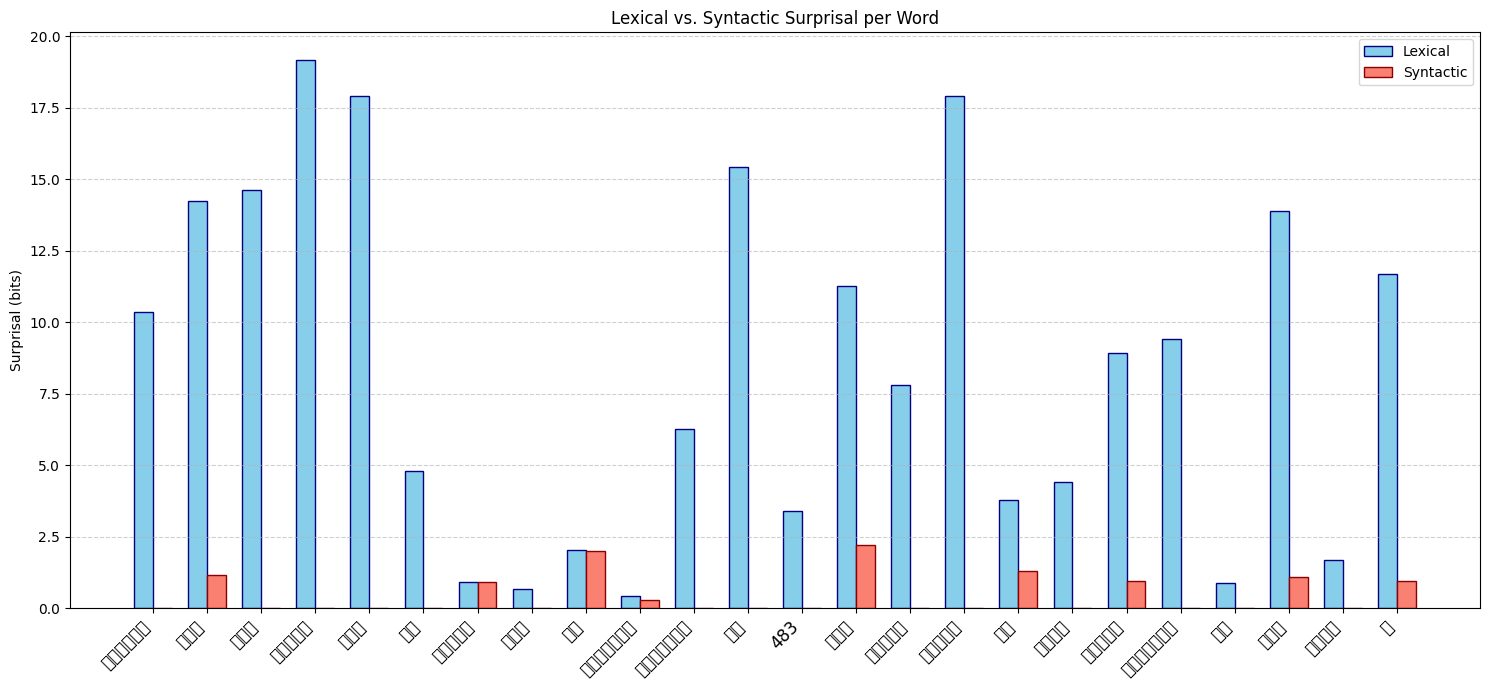

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

if 'df_surprise' not in globals() or df_surprise.empty:
    print('Run the previous analysis cell first to create df_surprise.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Plot 1: distribution comparison.
    max_val = float(max(df_surprise['lex_surprise'].max(), df_surprise['syn_surprise'].max()))
    bins = np.linspace(0, max_val, 40) if max_val > 0 else 20
    axes[0].hist(df_surprise['lex_surprise'], bins=bins, alpha=0.65, label='Lexical', color='steelblue')
    axes[0].hist(df_surprise['syn_surprise'], bins=bins, alpha=0.55, label='Syntactic', color='indianred')
    axes[0].set_title('Distribution of Lexical vs Syntactic Surprises')
    axes[0].set_xlabel('Surprise (bits)')
    axes[0].set_ylabel('Token count')
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    # Plot 2: average surprise by token position.
    pos_profile = (
        df_surprise.groupby('position')[['lex_surprise', 'syn_surprise']]
        .mean()
        .reset_index()
    )
    axes[1].plot(pos_profile['position'], pos_profile['lex_surprise'], marker='o', label='Lexical', color='steelblue')
    axes[1].plot(pos_profile['position'], pos_profile['syn_surprise'], marker='o', label='Syntactic', color='indianred')
    axes[1].set_title('Average Surprise by Word Position')
    axes[1].set_xlabel('Word position in sentence')
    axes[1].set_ylabel('Average surprise (bits)')
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


def plot_sentence_probability_profile(sentence, title_prefix='Sentence'):
    words = sentence.get_word_sequence()
    lex_probs = compute_lexical_probabilities(words)
    syn_probs = compute_syntactic_probabilities(sentence)

    x = np.arange(len(words))
    fig, ax = plt.subplots(1, 1, figsize=(14, 4))
    ax.plot(x, lex_probs, marker='o', label='Lexical probability P(w_i|w_{i-2},w_{i-1})', color='steelblue')
    ax.plot(x, syn_probs, marker='o', label='Syntactic probability P(s_i|s_{i-1})', color='indianred')
    ax.set_xticks(x)
    ax.set_xticklabels(words, rotation=45, ha='right')
    ax.set_ylabel('Probability')
    ax.set_title(f'{title_prefix}: Lexical vs Syntactic Token Probabilities')
    ax.legend()
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


# Set sentence indices here for probability plots (0-based).
SENTENCE_INDICES_FOR_PROB_PLOT = [0, 1, 2]
for idx in SENTENCE_INDICES_FOR_PROB_PLOT:
    if 0 <= idx < len(test_sentences):
        plot_sentence_probability_profile(test_sentences[idx], title_prefix=f'Test sentence {idx + 1}')


In [ ]:
# STEP 4B: PAPER-CONTEXT COMPARISON (HINDI VS ENGLISH)

def corpus_profile(sentences, language_label):
    if not sentences:
        return {
            'language': language_label,
            'num_sentences': 0,
            'avg_len': 0,
            'median_len': 0,
            'root_final_rate': 0,
            'preverbal_constituent_avg': 0,
        }

    lengths = []
    root_final = []
    preconst = []

    for s in sentences:
        toks = s.ordered_tokens()
        if not toks:
            continue
        lengths.append(len(toks))
        root = s.get_root()
        root_final.append(1 if root and root.id == len(toks) else 0)
        preconst.append(len(s.get_preverbal_constituents()))

    return {
        'language': language_label,
        'num_sentences': len(lengths),
        'avg_len': float(np.mean(lengths)) if lengths else 0,
        'median_len': float(np.median(lengths)) if lengths else 0,
        'root_final_rate': float(np.mean(root_final)) if root_final else 0,
        'preverbal_constituent_avg': float(np.mean(preconst)) if preconst else 0,
    }


profiles = [corpus_profile(test_sentences, 'Hindi (active run)')]
if 'english_test_sentences' in globals() and english_test_sentences:
    profiles.append(corpus_profile(english_test_sentences, 'English (optional)'))

profile_table = pd.DataFrame(profiles)
print('Corpus profile comparison:')
display(profile_table)

print('\nPaper context note:')
print('- The W18-4605 study adapts UID testing to Hindi free-word-order data.')
print('- English literature discussed in the paper focuses more on constrained word-order choices.')
print('- If English UD paths are configured, this table provides empirical contrast in your own setup.')


In [ ]:
# STEP 5: UID MEASURES (PAPER-STYLE)
import numpy as np

def mean_info(info_list):
    return sum(info_list) / len(info_list) if info_list else 0

def uid_global(info_list):
    if len(info_list) <= 1:
        return 0
    m = mean_info(info_list)
    variance = sum((x - m) ** 2 for x in info_list) / len(info_list)
    return -variance

def uid_local(info_list):
    if len(info_list) <= 1:
        return 0
    diffs = [(info_list[i] - info_list[i - 1]) ** 2 for i in range(1, len(info_list))]
    return -sum(diffs) / len(info_list)

def uid_global_norm(info_list):
    if len(info_list) <= 1:
        return 0
    m = mean_info(info_list)
    if m == 0:
        return 0
    return -sum(((x / m) - 1) ** 2 for x in info_list) / len(info_list)

def uid_local_norm(info_list):
    if len(info_list) <= 1:
        return 0
    m = mean_info(info_list)
    if m == 0:
        return 0
    diffs = [((info_list[i] - info_list[i - 1]) ** 2) / (m ** 2) for i in range(1, len(info_list))]
    return -sum(diffs) / len(info_list)

def uid_local_prev_norm(info_list):
    if len(info_list) <= 1:
        return 0
    diffs = []
    for i in range(1, len(info_list)):
        if info_list[i - 1] != 0:
            diffs.append(((info_list[i] / info_list[i - 1]) - 1) ** 2)
    return -sum(diffs) / len(info_list) if diffs else 0

def compute_all_uid(info_list):
    return {
        'UIDglob': uid_global(info_list),
        'UIDloc': uid_local(info_list),
        'UIDglobNorm': uid_global_norm(info_list),
        'UIDlocNorm': uid_local_norm(info_list),
        'UIDlocPrevNorm': uid_local_prev_norm(info_list)
    }

print("\nDEMO: UID scores for lexical surprisals of first dev sentence")
uid_example = compute_all_uid(lex_s)
for k, v in uid_example.items():
    print(f"{k:15s}: {v: .4f}")



DEMO: UID scores for lexical surprisals of first dev sentence
UIDglob        :  33.9758
UIDloc         :  6.2920
UIDglobNorm    :  4.5822
UIDlocNorm     :  0.8486
UIDlocPrevNorm :  3.4661


In [ ]:
# VARIANT GENERATOR (PAPER-ALIGNED)
# Generate non-canonical variants by permuting preverbal constituents,
# then filter permutations whose preverbal dependency sequence is attested in the corpus.


def constituent_head(constituent):
    ids = {t.id for t in constituent}
    for tok in constituent:
        if tok.head not in ids:
            return tok
    return constituent[0]


def preverbal_dependency_sequence(sentence):
    consts = sentence.get_preverbal_constituents()
    return tuple(constituent_head(c).deprel for c in consts)


def build_attested_preverbal_sequences(sentences):
    seqs = set()
    for sent in sentences:
        seq = preverbal_dependency_sequence(sent)
        if len(seq) > 1:
            seqs.add(seq)
    return seqs


ATTESTED_PREVERBAL_SEQS = build_attested_preverbal_sequences(train_sentences + dev_sentences + test_sentences)


def generate_variant(sentence, permutation):
    constituents = sentence.get_preverbal_constituents()
    if not constituents:
        return sentence

    ordered_tokens = sentence.ordered_tokens()

    permuted_tokens = []
    used_ids = set()
    for const_idx in permutation:
        for tok in constituents[const_idx]:
            permuted_tokens.append(tok)
            used_ids.add(tok.id)

    # Keep non-permuted material (including root/postverbal tokens) in original order.
    trailing_tokens = [tok for tok in ordered_tokens if tok.id not in used_ids]
    new_order = permuted_tokens + trailing_tokens

    old_to_new = {tok.id: i + 1 for i, tok in enumerate(new_order)}
    new_tokens = []
    for i, tok in enumerate(new_order, start=1):
        mapped_head = 0 if tok.head == 0 else old_to_new.get(tok.head, 0)
        new_tokens.append(Token(
            i,
            tok.form,
            tok.lemma,
            tok.upos,
            tok.xpos,
            tok.feats,
            mapped_head,
            tok.deprel,
            tok.deps,
            tok.misc,
        ))

    text = ' '.join(t.form for t in new_tokens)
    return Sentence(f"{sentence.sent_id}_var", text, new_tokens)


def generate_variants(sentence, max_var=99):
    constituents = sentence.get_preverbal_constituents()
    n_const = len(constituents)
    if n_const <= 1:
        return []

    original_perm = tuple(range(n_const))

    total_alt = math.factorial(n_const) - 1
    candidate_perms = []

    if total_alt <= max_var:
        for p in permutations(range(n_const)):
            if p != original_perm:
                candidate_perms.append(p)
    else:
        seen = {original_perm}
        while len(candidate_perms) < max_var:
            p = list(range(n_const))
            random.shuffle(p)
            p = tuple(p)
            if p in seen:
                continue
            seen.add(p)
            candidate_perms.append(p)

    variants = []
    seen_texts = set()

    for perm in candidate_perms:
        variant = generate_variant(sentence, perm)
        seq = preverbal_dependency_sequence(variant)

        # Paper-style filter: reject dependency-relation orders attested in corpus.
        if seq in ATTESTED_PREVERBAL_SEQS:
            continue

        if variant.text not in seen_texts:
            variants.append(variant)
            seen_texts.add(variant.text)

        if len(variants) >= max_var:
            break

    return variants


In [ ]:
# FEATURE EXTRACTION

def extract_features(sentence):
    features = {}
    words = sentence.get_word_sequence()
    lex_surp = compute_lexical_surprisal(words)
    syn_surp = compute_syntactic_surprisal(sentence)

    features['lex_sum'] = sum(lex_surp)
    features['syn_sum'] = sum(syn_surp)
    features['lex_mean'] = float(np.mean(lex_surp)) if lex_surp else 0.0
    features['syn_mean'] = float(np.mean(syn_surp)) if syn_surp else 0.0
    features['token_count'] = len(words)

    lex_uid = compute_all_uid(lex_surp)
    syn_uid = compute_all_uid(syn_surp)

    for k, v in lex_uid.items():
        features[f'lex_{k}'] = v
    for k, v in syn_uid.items():
        features[f'syn_{k}'] = v

    return features


In [ ]:
# STEP 6: GENERATE VARIANTS AND EXTRACT FEATURES
print('Generating variants and extracting features...')
corpus_features = []
variant_features = []
pair_count = 0
variant_count_by_sentence = []

for i, sentence in enumerate(test_sentences):
    variants = generate_variants(sentence, MAX_VARIANTS)
    variant_count_by_sentence.append(len(variants))

    if not variants:
        continue

    corp_feat = extract_features(sentence)
    for variant in variants:
        corpus_features.append(corp_feat)
        variant_features.append(extract_features(variant))
        pair_count += 1

print(f'Total pairs: {pair_count}')
print(f'Sentences with >=1 variant: {sum(1 for c in variant_count_by_sentence if c > 0)} / {len(test_sentences)}')
if variant_count_by_sentence:
    print(f'Average variants per sentence: {np.mean(variant_count_by_sentence):.2f}')

print("\nDEMO: Original vs one variant (first test sentence with at least one variant)")
demo_sent = next((s for s in test_sentences if generate_variants(s, 1)), None)
if demo_sent:
    v = generate_variants(demo_sent, 2)[0]
    print('Original:', demo_sent.text)
    print('Variant :', v.text)
    f_orig, f_var = extract_features(demo_sent), extract_features(v)
    print(f"\nlex_sum (orig, var): {round(f_orig['lex_sum'], 2)}, {round(f_var['lex_sum'], 2)}")


Generating variants and extracting features...
Total pairs: 28048

DEMO: Original vs one variant (first test sentence with at least one variant)
Original: इसके अतिरिक्त गुग्गुल कुंड, भीम गुफा तथा भीमशिला भी दर्शनीय स्थल हैं ।
Variant : अतिरिक्त तथा भी गुग्गुल गुफा भीमशिला इसके कुंड दर्शनीय , भीम स्थल हैं ।

lex_sum (orig, var): 172.31, 206.11


In [ ]:
# CLASSIFICATION FUNCTIONS

def make_diff(feat1, feat2):
    return [feat2[k] - feat1[k] for k in sorted(feat1.keys())]

def create_pairs(corp, var):
    X, y = [], []
    for c, v in zip(corp, var):
        X.append(make_diff(c, v))
        y.append(0)
    for c, v in zip(corp, var):
        X.append(make_diff(v, c))
        y.append(1)
    return np.array(X), np.array(y)

def cross_validate(X, y, n_folds=5):
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_SEED)
    accs, weights = [], []
    for tr_idx, te_idx in kf.split(X):
        clf = LogisticRegression(solver='lbfgs', max_iter=100)
        clf.fit(X[tr_idx], y[tr_idx])
        accs.append(clf.score(X[te_idx], y[te_idx]))
        weights.append(clf.coef_[0])
    return np.mean(accs), np.mean(weights, axis=0)

In [ ]:
# Define the experiment sets
experiments = [
    ('Lexical Surprisal only', ['lex_sum']),
    ('Syntactic Surprisal only', ['syn_sum']),
    ('Lexical UID only', ['lex_UIDglob', 'lex_UIDloc', 'lex_UIDglobNorm', 'lex_UIDlocNorm', 'lex_UIDlocPrevNorm']),
    ('Syntactic UID only', ['syn_UIDglob', 'syn_UIDloc', 'syn_UIDglobNorm', 'syn_UIDlocNorm', 'syn_UIDlocPrevNorm']),
    ('Lexical (Sum + UID)', ['lex_sum', 'lex_UIDglob', 'lex_UIDloc', 'lex_UIDglobNorm', 'lex_UIDlocNorm', 'lex_UIDlocPrevNorm']),
    ('All Features', ['lex_sum', 'syn_sum', 'lex_UIDglob', 'lex_UIDloc', 'syn_UIDglob', 'syn_UIDloc'])
]

print("\n" + "="*60)
print("STEP 7: CLASSIFICATION RESULTS (Table 1 style)")
print("="*60)

for name, feat_names in experiments:
    # Filter features based on the experiment definition
    corp = [{k: f[k] for k in feat_names if k in f} for f in corpus_features]
    var  = [{k: f[k] for k in feat_names if k in f} for f in variant_features]

    X, y = create_pairs(corp, var)
    acc, w = cross_validate(X, y, N_FOLDS)
    print(f"{name:30s}: {acc*100:5.2f}%   weights: {[round(float(x), 2) for x in w]}")

print("\nInterpretation:")
print("- Lexical surprisal usually yields the highest accuracy (~90%+).")
print("- UID features provide structural information but often lower accuracy than raw surprisal.")


STEP 7: CLASSIFICATION RESULTS (Table 1 style)
Lexical Surprisal only        : 98.15%   weights: [-0.27]
Syntactic Surprisal only      : 53.19%   weights: [0.1]
Lexical UID only              : 98.33%   weights: [-1.03, 10.85, 0.59, 1.9, -0.15]
Syntactic UID only            : 50.01%   weights: [0.0, 0.0, 0.0, -0.0, 0.0]
Lexical (Sum + UID)           : 98.39%   weights: [-0.38, 3.29, 0.65, 0.31, -0.35, -0.18]
All Features                  : 98.33%   weights: [-0.06, 0.6, -0.25, -0.06, 0.44, -0.14]

Interpretation:
- Lexical surprisal usually yields the highest accuracy (~90%+).
- UID features provide structural information but often lower accuracy than raw surprisal.


In [ ]:
# STEP 8A: DIAGNOSTICS FOR LEXICAL ACCURACY > 90%
if not corpus_features:
    print('Run variant generation and classification cells first.')
else:
    lex_c = np.array([f['lex_sum'] for f in corpus_features])
    lex_v = np.array([f['lex_sum'] for f in variant_features])
    syn_c = np.array([f['syn_sum'] for f in corpus_features])
    syn_v = np.array([f['syn_sum'] for f in variant_features])

    pair_table = pd.DataFrame({
        'lex_original': lex_c,
        'lex_variant': lex_v,
        'syn_original': syn_c,
        'syn_variant': syn_v,
        'token_count': [f['token_count'] for f in corpus_features],
    })
    pair_table['lex_prefers_original'] = pair_table['lex_original'] < pair_table['lex_variant']
    pair_table['syn_prefers_original'] = pair_table['syn_original'] < pair_table['syn_variant']
    pair_table['lex_margin'] = pair_table['lex_variant'] - pair_table['lex_original']
    pair_table['syn_margin'] = pair_table['syn_variant'] - pair_table['syn_original']

    def cohen_d(a, b):
        pooled = np.sqrt((np.var(a) + np.var(b)) / 2.0)
        return float((np.mean(a) - np.mean(b)) / pooled) if pooled > 0 else 0.0

    diagnostic_summary = pd.DataFrame([
        {'metric': 'lex_prefers_original_rate', 'value': float(pair_table['lex_prefers_original'].mean())},
        {'metric': 'syn_prefers_original_rate', 'value': float(pair_table['syn_prefers_original'].mean())},
        {'metric': 'mean_lex_margin_variant_minus_original', 'value': float(pair_table['lex_margin'].mean())},
        {'metric': 'mean_syn_margin_variant_minus_original', 'value': float(pair_table['syn_margin'].mean())},
        {'metric': 'cohen_d_lex_variant_vs_original', 'value': cohen_d(lex_v, lex_c)},
        {'metric': 'cohen_d_syn_variant_vs_original', 'value': cohen_d(syn_v, syn_c)},
        {'metric': 'corr_lex_margin_with_length', 'value': float(pair_table['lex_margin'].corr(pair_table['token_count']))},
    ])

    print('Lexical >90% investigation summary:')
    display(diagnostic_summary)

    print('\nPairwise lexical/syntactic comparison (sample):')
    display(pair_table.head(20))


In [ ]:
# STEP 8: CORRELATION ANALYSIS (TABLE 2)
from scipy.stats import pearsonr

def pearson_corr(x, y):
    if len(set(x)) <= 1 or len(set(y)) <= 1: return 0
    return pearsonr(x, y)[0]

print('\n' + '='*60)
print('CORRELATION ANALYSIS (Table 2)')
print('='*60)

lex_surp = [f['lex_sum'] for f in corpus_features]
syn_surp = [f['syn_sum'] for f in corpus_features]

print('\nLexical Surprisal vs UID:')
for name in ['UIDglob', 'UIDloc', 'UIDglobNorm', 'UIDlocNorm', 'UIDlocPrevNorm']:
    feat_key = f'lex_{name}'
    vals = [f[feat_key] for f in corpus_features if feat_key in f]
    if vals:
        print(f"  {name:20s}: {pearson_corr(lex_surp[:len(vals)], vals):7.4f}")

print("\nSummary:\n- UID variants correlate moderately with surprisal.\n- UID does not outrun surprisal in classification.")


CORRELATION ANALYSIS (Table 2)

Lexical Surprisal vs UID:


NameError: name 'pearson_corr' is not defined

## Replication Notes (Corrected Paper Alignment)

This notebook now aligns the implementation with the corrected W18-4605 setup where possible:

- Lexical surprise: trigram surprisal `-log2 P(w_i | w_{i-2}, w_{i-1})`
- Syntactic surprise: transition-based approximation of parser-state surprisal (since SRILM/incremental parser is not used here)
- Variant generation: permutation of preverbal constituents with attested dependency-sequence filtering
- Added diagnostics requested in this pass:
  - sentence-volume checks and profile presets
  - lexical >90% accuracy investigation table
  - lexical/syntactic probability plots for given sentences
  - lexical-vs-syntactic comparison tables
  - optional Hindi-vs-English corpus profile comparison (if English paths are set)
